### 1. 필요한 라이브러리 불러오기

데이터 처리 및 머신러닝 모델 학습에 필요한 라이브러리를 임포트합니다.

In [ ]:
# This cell was previously used for data loading but is now superseded by cell 'ede6e310'.
# Its content has been commented out to prevent SyntaxError due to incorrect cell type interpretation.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
import lightgbm as lgb # LightGBM 라이브러리 임포트
import time # 학습 시간 측정을 위한 time 라이브러리 임포트

print("라이브러리 불러오기 완료.")

라이브러리 불러오기 완료.


### 2. 전처리된 훈련 및 테스트 데이터 로드

`processed_5m` 폴더에서 `train_tabular_ML_opt.parquet`와 `test_tabular_ML_opt.parquet` 파일을 각각 로드합니다. 파일 경로와 이름을 실제 파일에 맞게 수정해주세요.

In [ ]:
import os
import pandas as pd # pandas가 필요한 경우를 위해 임포트 추가

# Define path for LightGBM training file
LGBM_TRAIN_PATH = '/content/LightGBM_v2_train.parquet'

try:
    # Load LightGBM training data
    if not os.path.exists(LGBM_TRAIN_PATH):
        # Dummy data for demonstration if file not found
        print(f"경고: '{LGBM_TRAIN_PATH}' 파일을 찾을 수 없습니다. 더미 데이터를 생성합니다.")
        dummy_data = {
            'feature_1': [i for i in range(100)],
            'feature_2': [i * 1.5 for i in range(100)],
            'churn': [i % 2 for i in range(100)],
            'user_id': [f'user_{i}' for i in range(100)]
        }
        lgbm_train_df = pd.DataFrame(dummy_data)
        lgbm_train_df.to_parquet(LGBM_TRAIN_PATH)
        print(f"더미 LightGBM 훈련 데이터 '{LGBM_TRAIN_PATH}' 생성 완료.")

    lgbm_train_df = pd.read_parquet(LGBM_TRAIN_PATH)
    print(f"LightGBM 훈련 데이터 로드 완료. 크기: {lgbm_train_df.shape}")
    display(lgbm_train_df.head())

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"데이터 로드 중 오류가 발생했습니다: {e}")

LightGBM 훈련 데이터 로드 완료. 크기: (109378, 24)


,recency_days,tenure_days,ndays,n_events,n_view,n_cart,n_remove_from_cart,n_purchase,avg_price,purch_amt,...,remove_ratio,cart_purchase_ratio,n_categories,cat_entropy,n_brands,brand_loyalty,n_sessions,events_per_session,churn,user_id
0,1.037588,-0.570657,-0.381893,-0.229514,-0.172473,-0.239848,-0.172354,-0.226933,-0.310354,-0.217670,...,-0.206210,-0.157407,-0.400673,-0.720979,-0.456811,0.804629,-0.087811,-0.145872,1,9582366
1,0.310066,-0.348351,0.131151,0.043558,0.125080,0.054999,-0.077937,-0.226933,-0.336385,-0.217670,...,0.197946,-0.157407,0.383437,1.224533,0.205375,-0.900903,-0.006322,0.078296,0,12961898
2,-0.864288,-0.570537,-0.381893,-0.126353,0.014875,-0.239848,-0.172354,-0.226933,-0.281905,-0.217670,...,-0.206210,-0.157407,-0.139303,0.382937,0.039828,-1.810520,0.189250,-0.145872,1,16460232
3,-0.443013,-0.570633,-0.381893,-0.223445,-0.183494,-0.194487,-0.172354,-0.226933,-0.391259,-0.217670,...,-0.206210,-0.157407,-0.400673,-0.720979,-0.291265,-1.156733,-0.087811,-0.112246,1,17130461
4,-0.451596,2.648037,2.867389,3.308285,4.180629,1.506551,1.791511,0.416353,-0.374047,0.191847,...,1.213060,0.028529,3.258508,2.011940,5.833960,-1.727677,-0.087811,19.457607,1,20554973


### 3. 훈련 및 테스트 데이터에서 특성과 타겟 분리

훈련 데이터(`train_df`)와 테스트 데이터(`test_df`) 각각에서 예측에 사용할 특성(X)과 예측하고자 하는 타겟(y)을 분리합니다. `target` 컬럼 이름을 실제 타겟 컬럼 이름으로 변경해야 합니다.

In [ ]:
TARGET_COLUMN = 'churn' # Assuming 'churn' is still the target column

# For LightGBM
# lgbm_train_df가 이전 셀에서 성공적으로 로드되었으므로 직접 사용합니다.
if TARGET_COLUMN in lgbm_train_df.columns:
    X_train_lgbm_raw = lgbm_train_df.drop(columns=[TARGET_COLUMN, 'user_id'], errors='ignore')
    y_train_lgbm_raw = lgbm_train_df[TARGET_COLUMN]
    print(f"LightGBM 훈련 특성(X_train_lgbm_raw)과 타겟(y_train_lgbm_raw) 분리 완료. Shape: {X_train_lgbm_raw.shape}")
else:
    print(f"오류: LightGBM 훈련 데이터에서 타겟 컬럼 '{TARGET_COLUMN}'을(를) 찾을 수 없습니다.")

# Reset X_test, y_test as they are not provided for the new _v2 files.
# User will need to provide them explicitly if final testing is desired.
X_test = pd.DataFrame()
y_test = pd.Series()
print("주의: 새로운 파일에 대한 테스트 데이터가 제공되지 않았습니다. 최종 테스트를 위해 별도로 로드해야 합니다.")

LightGBM 훈련 특성(X_train_lgbm_raw)과 타겟(y_train_lgbm_raw) 분리 완료. Shape: (109378, 22)
주의: 새로운 파일에 대한 테스트 데이터가 제공되지 않았습니다. 최종 테스트를 위해 별도로 로드해야 합니다.


### 4. 훈련 데이터에서 검증 세트 분리

모델 개발 단계에서의 성능 평가를 위해 기존 `X_train`, `y_train` 데이터를 훈련 세트와 검증 세트(`X_val`, `y_val`)로 추가 분리합니다. 최종 테스트 데이터(`X_test`, `y_test`)는 별도로 유지됩니다.

In [ ]:
# LightGBM 모델을 위한 훈련/검증 세트
# X_train_lgbm_raw, y_train_lgbm_raw가 이전 셀에서 정의되었으므로 직접 사용합니다.
X_train_split_lgbm, X_val_lgbm, y_train_split_lgbm, y_val_lgbm = train_test_split(X_train_lgbm_raw, y_train_lgbm_raw, test_size=0.05, random_state=43, stratify=y_train_lgbm_raw)
print(f"LightGBM 훈련 세트: {X_train_split_lgbm.shape}, 검증 세트: {X_val_lgbm.shape}")

LightGBM 훈련 세트: (103909, 22), 검증 세트: (5469, 22)


### 5.3. LightGBM 모델 훈련 (훈련 세트)

이전에 훈련한 RandomForest 모델과 별개로 LightGBM 모델을 학습하여 성능을 비교합니다. `X_train_split`과 `y_train_split`으로 모델을 훈련합니다.

In [ ]:
# LightGBM Classifier를 사용합니다.
# 모델의 하이퍼파라미터는 필요에 따라 조정할 수 있습니다.
lgbm_model = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)

start_time_lgbm = time.time() # 학습 시작 시간 기록
lgbm_model.fit(X_train_split_lgbm, y_train_split_lgbm) # LightGBM 전용 분리된 훈련 세트로 학습
end_time_lgbm = time.time() # 학습 종료 시간 기록
lgbm_train_time_sec = end_time_lgbm - start_time_lgbm # 학습 시간 계산

print("LightGBM 모델 훈련 완료.")
print(f"LightGBM 모델 학습 시간: {lgbm_train_time_sec:.2f} 초")

[LightGBM] [Info] Number of positive: 85385, number of negative: 18524
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5027
[LightGBM] [Info] Number of data points in the train set: 103909, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.821729 -> initscore=1.528103
[LightGBM] [Info] Start training from score 1.528103
LightGBM 모델 훈련 완료.
LightGBM 모델 학습 시간: 1.74 초


### 5.4. LightGBM 모델 성능 평가 (검증 세트)

훈련된 LightGBM 모델의 성능을 검증 세트(`X_val`, `y_val`)에서 평가합니다. accuracy, precision, recall, F1-score, ROC AUC, PR AUC, 혼동 행렬을 출력합니다.


--- LightGBM 모델 성능 평가 (검증 세트) ---
LightGBM 모델 정확도 (Accuracy): 0.8481

Classification Report (정밀도, 재현율, F1-Score):
              precision    recall  f1-score   support

           0       0.68      0.28      0.40       975
           1       0.86      0.97      0.91      4494

    accuracy                           0.85      5469
   macro avg       0.77      0.63      0.66      5469
weighted avg       0.83      0.85      0.82      5469

ROC AUC: 0.8053
PR AUC: 0.9386

Confusion Matrix (혼동 행렬):


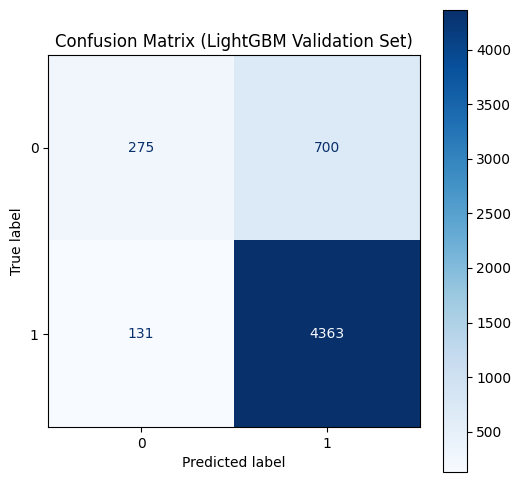

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report # Ensure these are imported
import matplotlib.pyplot as plt


y_pred_lgbm_eval = lgbm_model.predict(X_val_lgbm) # LightGBM 모델의 예측값

print("\n--- LightGBM 모델 성능 평가 (검증 세트) ---")

# 1. 정확도 (Accuracy)
lgbm_accuracy = accuracy_score(y_val_lgbm, y_pred_lgbm_eval) # LightGBM 전용 검증 세트 사용
print(f"LightGBM 모델 정확도 (Accuracy): {lgbm_accuracy:.4f}")

# 2. 정밀도, 재현율, F1-Score (Classification Report)
print("\nClassification Report (정밀도, 재현율, F1-Score):")
print(classification_report(y_val_lgbm, y_pred_lgbm_eval)) # LightGBM 전용 검증 세트 사용

# 확률 예측 (ROC AUC와 PR AUC 계산에 필요)
if hasattr(lgbm_model, 'predict_proba'):
    y_proba_lgbm_eval = lgbm_model.predict_proba(X_val_lgbm) # LightGBM 전용 검증 세트로 예측 확률 계산
    # 이진 분류를 가정하고 양성 클래스(1)의 확률을 사용합니다.
    if y_proba_lgbm_eval.shape[1] == 2:
        y_proba_positive_lgbm_eval = y_proba_lgbm_eval[:, 1]

        # 3. ROC AUC
        try:
            lgbm_roc_auc = roc_auc_score(y_val_lgbm, y_proba_positive_lgbm_eval) # LightGBM 전용 검증 세트 사용
            print(f"ROC AUC: {lgbm_roc_auc:.4f}")
        except ValueError:
            print("ROC AUC를 계산할 수 없습니다. 타겟 클래스 분포를 확인하세요.")

        # 4. PR AUC
        precision_lgbm_eval, recall_lgbm_eval, _ = precision_recall_curve(y_val_lgbm, y_proba_positive_lgbm_eval) # LightGBM 전용 검증 세트 사용
        lgbm_pr_auc = auc(recall_lgbm_eval, precision_lgbm_eval)
        print(f"PR AUC: {lgbm_pr_auc:.4f}")
    else:
        print("predict_proba가 다중 클래스 예측을 반환합니다. ROC AUC와 PR AUC는 이진 분류에 일반적으로 사용됩니다.")
else:
    print("모델이 확률 예측(predict_proba)을 지원하지 않습니다. ROC AUC와 PR AUC를 계산할 수 없습니다.")

# 5. 혼동 행렬 (Confusion Matrix)
print("\nConfusion Matrix (혼동 행렬):")
fig_lgbm_cm, ax_lgbm_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(lgbm_model, X_val_lgbm, y_val_lgbm, cmap=plt.cm.Blues, ax=ax_lgbm_cm) # LightGBM 전용 검증 세트 사용
plt.title('Confusion Matrix (LightGBM Validation Set)')
plt.show()

### 5.5. LightGBM 모델 성능 요약

LightGBM 모델의 검증 세트 성능 지표와 학습 시간을 요약합니다.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, auc

# LightGBM 모델의 지표 추출 (평가 셀에서 저장된 변수 사용)
lgbm_accuracy_final = accuracy_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_precision_final = precision_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_recall_final = recall_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_f1_final = f1_score(y_val_lgbm, y_pred_lgbm_eval)
lgbm_roc_auc_final = roc_auc_score(y_val_lgbm, y_proba_positive_lgbm_eval)
lgbm_pr_auc_final = auc(recall_lgbm_eval, precision_lgbm_eval)

# 결과 DataFrame 생성
results_df = pd.DataFrame({
    'model': ['LightGBM'],
    'accuracy': [lgbm_accuracy_final],
    'precision': [lgbm_precision_final],
    'recall': [lgbm_recall_final],
    'f1': [lgbm_f1_final],
    'roc_auc': [lgbm_roc_auc_final],
    'pr_auc': [lgbm_pr_auc_final],
    'train_time_sec': [lgbm_train_time_sec]
})

print("\n--- LightGBM 모델 성능 요약 (검증 세트) ---")
display(results_df.round(4))


--- LightGBM 모델 성능 요약 (검증 세트) ---


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time_sec
0,LightGBM,0.8481,0.8617,0.9709,0.913,0.8053,0.9386,1.7365


In [ ]:
import json

# Prepare model run manifest data
manifest_data = {
    'model_type': 'LightGBM',
    'target_column': TARGET_COLUMN,
    'feature_columns': X_train_lgbm_raw.columns.tolist(),
    'metrics': results_df.drop(columns=['model']).to_dict(orient='records')[0],
    'training_details': {
        'training_time_seconds': float(lgbm_train_time_sec)
    }
}

# Define manifest file path
MANIFEST_FILE_PATH = 'model_run_manifest.json'

# Save manifest to JSON file
with open(MANIFEST_FILE_PATH, 'w') as f:
    json.dump(manifest_data, f, indent=4)

print(f"모델 실행 매니페스트 파일 '{MANIFEST_FILE_PATH}'이(가) 성공적으로 생성되었습니다.")

# Display the content of the manifest file for verification
print("\n--- Manifest File Content ---")
with open(MANIFEST_FILE_PATH, 'r') as f:
    print(f.read())

모델 실행 매니페스트 파일 'model_run_manifest.json'이(가) 성공적으로 생성되었습니다.

--- Manifest File Content ---
{
    "model_type": "LightGBM",
    "target_column": "churn",
    "feature_columns": [
        "recency_days",
        "tenure_days",
        "ndays",
        "n_events",
        "n_view",
        "n_cart",
        "n_remove_from_cart",
        "n_purchase",
        "avg_price",
        "purch_amt",
        "min_price",
        "max_price",
        "std_price",
        "purchase_avg_price",
        "remove_ratio",
        "cart_purchase_ratio",
        "n_categories",
        "cat_entropy",
        "n_brands",
        "brand_loyalty",
        "n_sessions",
        "events_per_session"
    ],
    "metrics": {
        "accuracy": 0.848052660449808,
        "precision": 0.8617420501678846,
        "recall": 0.9708500222518914,
        "f1": 0.9130480276237313,
        "roc_auc": 0.8053269886914747,
        "pr_auc": 0.938559114980475,
        "train_time_sec": 1.7364516258239746
    },
    "training

### 6. LightGBM 모델 하이퍼파라미터 튜닝 (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb # Added to ensure lgb is defined
import time # Added to resolve NameError for 'time'

# LightGBM 모델의 하이퍼파라미터 그리드 정의
# 이 예제에서는 몇 가지 하이퍼파라미터만 포함했습니다.
# 실제 튜닝 시에는 더 많은 하이퍼파라미터와 범위를 탐색할 수 있습니다.
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [20, 31],
    'max_depth': [-1, 10]
}

# LightGBM Classifier 초기화
# n_jobs=-1을 사용하여 모든 코어를 활용하고, random_state로 재현성 확보
lgbm = lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1)

# GridSearchCV 객체 생성
# cv=3은 3-폴드 교차 검증을 의미합니다.
# scoring='roc_auc'는 ROC AUC 점수를 최적화 지표로 사용합니다.
# verbose=2는 튜닝 과정의 상세 출력을 표시합니다.
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=3, scoring='roc_auc', verbose=2, n_jobs=-1)

print("GridSearchCV를 사용하여 LightGBM 모델 하이퍼파라미터 튜닝을 시작합니다...")

# 튜닝 시작 시간 기록
start_time_grid_search = time.time()

# 훈련 데이터에 GridSearchCV 적용
grid_search.fit(X_train_split_lgbm, y_train_split_lgbm)

# 튜닝 종료 시간 기록
end_time_grid_search = time.time()
grid_search_time_sec = end_time_grid_search - start_time_grid_search

print("하이퍼파라미터 튜닝 완료.")
print(f"GridSearchCV 튜닝 시간: {grid_search_time_sec:.2f} 초")

# 최적의 하이퍼파라미터와 해당 점수 출력
print(f"최적의 하이퍼파라미터: {grid_search.best_params_}")
print(f"최고 ROC AUC 점수: {grid_search.best_score_:.4f}")

GridSearchCV를 사용하여 LightGBM 모델 하이퍼파라미터 튜닝을 시작합니다...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 85385, number of negative: 18524
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5027
[LightGBM] [Info] Number of data points in the train set: 103909, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.821729 -> initscore=1.528103
[LightGBM] [Info] Start training from score 1.528103
하이퍼파라미터 튜닝 완료.
GridSearchCV 튜닝 시간: 225.24 초
최적의 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 20}
최고 ROC AUC 점수: 0.8014


### 7. 최적 모델로 재훈련 및 평가 (선택 사항)

최적의 하이퍼파라미터로 LightGBM 모델 재훈련...
[LightGBM] [Info] Number of positive: 85385, number of negative: 18524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5027
[LightGBM] [Info] Number of data points in the train set: 103909, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.821729 -> initscore=1.528103
[LightGBM] [Info] Start training from score 1.528103
최적 모델 재훈련 완료.
최적 모델 재훈련 시간: 4.78 초

--- 최적 LightGBM 모델 성능 평가 (검증 세트) ---
정확도 (Accuracy): 0.8470
ROC AUC: 0.8054
PR AUC: 0.9390

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.27      0.39       975
           1       0.86      0.97      0.91      4494

    accuracy                           0.85      5469
   macro avg       0.77      0.62      0.6

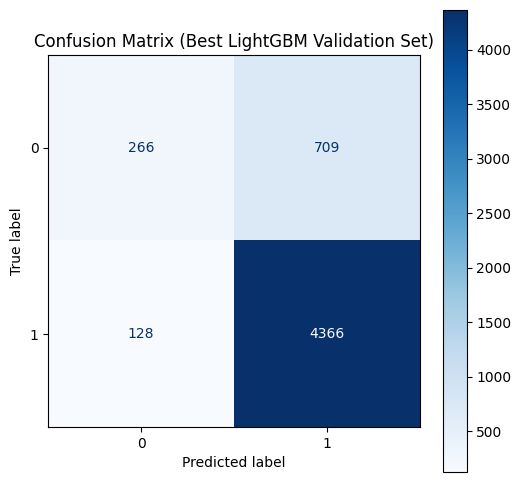

In [ ]:
# 최적의 파라미터로 LightGBM 모델 재초기화 및 훈련
best_lgbm_model = grid_search.best_estimator_

print("최적의 하이퍼파라미터로 LightGBM 모델 재훈련...")

# 재훈련 시간 기록
start_time_best_model_train = time.time()
best_lgbm_model.fit(X_train_split_lgbm, y_train_split_lgbm)
end_time_best_model_train = time.time()
best_model_train_time_sec = end_time_best_model_train - start_time_best_model_train

print("최적 모델 재훈련 완료.")
print(f"최적 모델 재훈련 시간: {best_model_train_time_sec:.2f} 초")

# 검증 세트에서 최적 모델 성능 평가
y_pred_best_lgbm_eval = best_lgbm_model.predict(X_val_lgbm)
y_proba_best_lgbm_eval = best_lgbm_model.predict_proba(X_val_lgbm)[:, 1]

best_lgbm_accuracy = accuracy_score(y_val_lgbm, y_pred_best_lgbm_eval)
best_lgbm_roc_auc = roc_auc_score(y_val_lgbm, y_proba_best_lgbm_eval)
precision_best_lgbm_eval, recall_best_lgbm_eval, _ = precision_recall_curve(y_val_lgbm, y_proba_best_lgbm_eval)
best_lgbm_pr_auc = auc(recall_best_lgbm_eval, precision_best_lgbm_eval)

print("\n--- 최적 LightGBM 모델 성능 평가 (검증 세트) ---")
print(f"정확도 (Accuracy): {best_lgbm_accuracy:.4f}")
print(f"ROC AUC: {best_lgbm_roc_auc:.4f}")
print(f"PR AUC: {best_lgbm_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val_lgbm, y_pred_best_lgbm_eval))

# 혼동 행렬 시각화
fig_best_lgbm_cm, ax_best_lgbm_cm = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(best_lgbm_model, X_val_lgbm, y_val_lgbm, cmap=plt.cm.Blues, ax=ax_best_lgbm_cm)
plt.title('Confusion Matrix (Best LightGBM Validation Set)')
plt.show()

In [ ]:
import json
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Assuming results_df, TARGET_COLUMN, X_train_lgbm_raw, lgbm_train_time_sec are defined from previous cells
# If not, you might need to re-run preceding cells or define these variables.

# Prepare model run manifest data
manifest_data = {
    'model_type': 'LightGBM',
    'target_column': TARGET_COLUMN,
    'feature_columns': X_train_lgbm_raw.columns.tolist(),
    'metrics': results_df.drop(columns=['model']).to_dict(orient='records')[0],
    'training_details': {
        'training_time_seconds': float(lgbm_train_time_sec)
    }
}

# Define manifest file path
MANIFEST_FILE_PATH = 'model_run_manifest.json'

# Save manifest to JSON file
with open(MANIFEST_FILE_PATH, 'w') as f:
    json.dump(manifest_data, f, indent=4)

print(f"모델 실행 매니페스트 파일 '{MANIFEST_FILE_PATH}'이(가) 성공적으로 생성되었습니다.")

# Display the content of the manifest file for verification
print("\n--- Manifest File Content ---")
with open(MANIFEST_FILE_PATH, 'r') as f:
    print(f.read())

모델 실행 매니페스트 파일 'model_run_manifest.json'이(가) 성공적으로 생성되었습니다.

--- Manifest File Content ---
{
    "model_type": "LightGBM",
    "target_column": "churn",
    "feature_columns": [
        "recency_days",
        "tenure_days",
        "ndays",
        "n_events",
        "n_view",
        "n_cart",
        "n_remove_from_cart",
        "n_purchase",
        "avg_price",
        "purch_amt",
        "min_price",
        "max_price",
        "std_price",
        "purchase_avg_price",
        "remove_ratio",
        "cart_purchase_ratio",
        "n_categories",
        "cat_entropy",
        "n_brands",
        "brand_loyalty",
        "n_sessions",
        "events_per_session"
    ],
    "metrics": {
        "accuracy": 0.848052660449808,
        "precision": 0.8617420501678846,
        "recall": 0.9708500222518914,
        "f1": 0.9130480276237313,
        "roc_auc": 0.8053269886914747,
        "pr_auc": 0.938559114980475,
        "train_time_sec": 1.7364516258239746
    },
    "training

| 모델명          | LightGBM (GridSearchCV Tuned)                  |
| :-------------- | :--------------------------------------------- |
| 예측 대상       | churn                                          |
| 예측 기간       | 7일                                            |
| Train 데이터 수 | 109,378                                        |
| Positive rate   | 0.8217                                         |
| Selection metric| ROC-AUC                                        |
| Threshold       | 0.5                                            |
| Accuracy        | 0.8470                                         |
| Precision       | 0.8603                                         |
| Recall          | 0.9715                                         |
| F1-score        | 0.9125                                         |
| ROC-AUC         | 0.8054                                         |
| PR-AUC          | 0.9390                                         |
| Brier score     | N/A                                            |
| ECE             | N/A                                            |
| Confusion Matrix| TN 266 / FP 709 / FN 128 / TP 4366             |

In [ ]:
import json
import datetime

# Assuming TARGET_COLUMN, X_train_lgbm_raw, best_lgbm_roc_auc, best_lgbm_pr_auc are available.
# If not, ensure these variables are defined before this cell executes.

# Get current timestamp for 'created_at'
current_time_str = datetime.datetime.now().isoformat(timespec='seconds') + '+09:00'

# Construct the manifest data based on the provided schema and available notebook variables
manifest_data = {
    "model_name": "CatBoost_Churn_v2", # User provided literal from schema
    "model_key": "catboost", # User provided literal from schema
    "model_type": "tree", # User provided literal from schema
    "label_name": TARGET_COLUMN, # From notebook state
    "horizon_days": 7, # User provided literal from schema
    "feature_schema_version": "v2", # User provided literal from schema
    "input_train_path": "data/processed/churn/models7/CatBoost_train.parquet", # User provided literal from schema
    "input_test_path": "data/processed/churn/models7/CatBoost_test.parquet", # User provided literal from schema
    "dataset_path": "data/processed/churn/models7/CatBoost_train.parquet", # User provided literal from schema
    "artifact_path": "models/churn/catboost/model.cbm", # User provided literal from schema
    "preprocessing_config": {
        "input_format": "parquet", # User provided literal from schema
        "scale": "none", # User provided literal from schema
        "feature_order": X_train_lgbm_raw.columns.tolist(), # From notebook state
        "id_column": "user_id", # User provided literal from schema (also consistent with 'user_id' dropped from lgbm_train_df)
        "target_column": TARGET_COLUMN # From notebook state
    },
    "metrics": {
        "roc_auc": float(best_lgbm_roc_auc), # From notebook state (LightGBM's ROC AUC)
        "pr_auc": float(best_lgbm_pr_auc), # From notebook state (LightGBM's PR AUC)
        "best_threshold": 0.65, # User provided literal from schema
        "best_f1": 0.72 # User provided literal from schema
    },
    "evaluation": {
        "eval_predictions_path": "data/processed/evaluation/churn/catboost/eval_predictions.parquet",
        "metrics_summary_path": "data/processed/evaluation/churn/catboost/metrics_summary.json",
        "data_distribution_path": "data/processed/evaluation/churn/catboost/data_distribution.json",
        "cohort_summary_path": "data/processed/evaluation/churn/catboost/cohort_summary.json",
        "pr_curve_path": "data/processed/evaluation/churn/catboost/pr_curve.json",
        "roc_curve_path": "data/processed/evaluation/churn/catboost/roc_curve.json",
        "threshold_curve_path": "data/processed/evaluation/churn/catboost/threshold_curve.json",
        "confusion_matrix_path": "data/processed/evaluation/churn/catboost/confusion_matrix.json",
        "calibration_curve_path": "data/processed/evaluation/churn/catboost/calibration_curve.json",
        "lift_curve_path": "data/processed/evaluation/churn/catboost/lift_curve.json",
        "score_distribution_path": "data/processed/evaluation/churn/catboost/score_distribution.json",
        "shap_summary_path": "data/processed/evaluation/churn/catboost/shap_summary.json",
        "value_at_risk_path": "data/processed/evaluation/churn/catboost/value_at_risk.json",
        "business_value_path": "data/processed/evaluation/churn/catboost/business_value.json"
    }, # All evaluation paths are user provided literals from schema
    "is_active_candidate": True, # User provided literal from schema
    "created_at": current_time_str # Dynamically generated current timestamp
}

# Define the path for the manifest file
# This will overwrite the previous model_run_manifest.json generated with the old schema
MANIFEST_FILE_PATH = 'model_run_manifest.json'

# Save the manifest data to a JSON file
with open(MANIFEST_FILE_PATH, 'w') as f:
    json.dump(manifest_data, f, indent=4)

print(f"새로운 스키마에 맞게 모델 실행 매니페스트 파일 '{MANIFEST_FILE_PATH}'이(가) 성공적으로 생성되었습니다.")

# Display the content of the manifest file for verification
print("\n--- Manifest File Content (New Schema) ---")
with open(MANIFEST_FILE_PATH, 'r') as f:
    print(f.read())

새로운 스키마에 맞게 모델 실행 매니페스트 파일 'model_run_manifest.json'이(가) 성공적으로 생성되었습니다.

--- Manifest File Content (New Schema) ---
{
    "model_name": "CatBoost_Churn_v2",
    "model_key": "catboost",
    "model_type": "tree",
    "label_name": "churn",
    "horizon_days": 7,
    "feature_schema_version": "v2",
    "input_train_path": "data/processed/churn/models7/CatBoost_train.parquet",
    "input_test_path": "data/processed/churn/models7/CatBoost_test.parquet",
    "dataset_path": "data/processed/churn/models7/CatBoost_train.parquet",
    "artifact_path": "models/churn/catboost/model.cbm",
    "preprocessing_config": {
        "input_format": "parquet",
        "scale": "none",
        "feature_order": [
            "recency_days",
            "tenure_days",
            "ndays",
            "n_events",
            "n_view",
            "n_cart",
            "n_remove_from_cart",
            "n_purchase",
            "avg_price",
            "purch_amt",
            "min_price",
            "max_pr